In [31]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload
%autoreload 2

import os
os.chdir(os.path.expanduser("/workspaces/capstone_imperial_ml_ai/src"))

from ml.data import DataLoader, TransformUtils
from ml.plot import PlotUtils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
X, y = DataLoader.load_all_function_data(function_name="function_1")

Loaded data from /workspaces/capstone_imperial_ml_ai/data/initial_data/function_1
Input shape: (10, 2), Output shape: (10,)
Loaded submission data from /workspaces/capstone_imperial_ml_ai/data/submissions/function_1.json
Submission input shape: (1, 2), output shape: (1,)


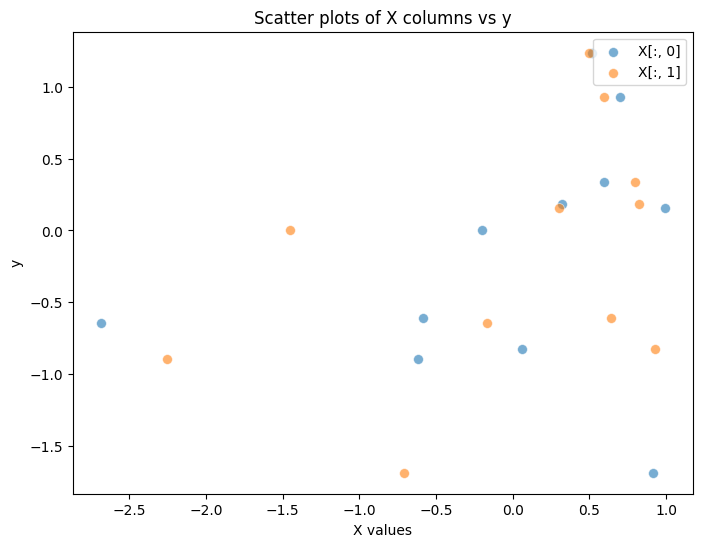

In [33]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline

x_scaler = StandardScaler(with_mean=True, with_std=True)
y_scaler = RobustScaler()

x_log = np.log(np.abs(X))
y_log = np.log(np.abs(y)).reshape(-1, 1)

X_transformed = x_scaler.fit_transform(x_log)
y_transformed = y_scaler.fit_transform(y_log).ravel()

PlotUtils.scatter(X_transformed, y_transformed)

In [36]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

# 1. Matern(nu=2.5): The 5/2 kernel we discussed.
# 2. WhiteKernel: This handles "Noise". It tells the model 
#    "The data isn't perfect, allow for some wiggle room."
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 10.0), nu=2.5) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100, normalize_y=True)

model.fit(X_transformed, y_transformed)


print("Model Trained.")
print(f"Learned Kernel Parameters: {model.kernel_}")


/workspaces/capstone_imperial_ml_ai/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,Matern(length...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,100
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length...1, 1], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__length_scale,"[1.0, 1.0]"


Model Trained.
Learned Kernel Parameters: Matern(length_scale=[0.541, 0.348], nu=2.5) + WhiteKernel(noise_level=1e-05)


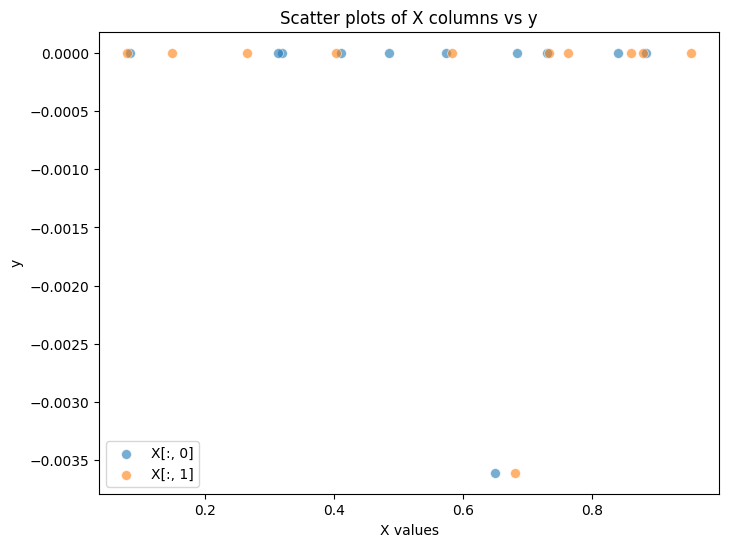

In [37]:
PlotUtils.scatter(X, y)

In [38]:
def predict(X_new):
    X_new_log = np.log(np.abs(X_new))
    X_new_transformed = x_scaler.transform(X_new_log)
    y_pred_transformed, y_std_transformed = model.predict(X_new_transformed, return_std=True)
    y_pred_log = y_scaler.inverse_transform(y_pred_transformed.reshape(-1, 1)).ravel()
    y_pred = -1 * np.exp(y_pred_log)
    return y_pred, y_std_transformed

x_space = np.linspace(0.6, 0.70, 10)
x_space = np.array([[x1, x1] for x1 in x_space])
y_pred, y_std = predict(x_space)
print("Predictions:")
for xi, yi, si in zip(x_space, y_pred, y_std):
    print(f"X: {xi}, Predicted y: {yi}, Std Dev: {si}")

Predictions:
X: [0.6 0.6], Predicted y: -3.664784535203939e-15, Std Dev: 0.3917233745049321
X: [0.61111111 0.61111111], Predicted y: -4.169900729852821e-12, Std Dev: 0.33132196432897026
X: [0.62222222 0.62222222], Predicted y: -1.9596185654646737e-09, Std Dev: 0.270046420254736
X: [0.63333333 0.63333333], Predicted y: -3.019347173077998e-07, Std Dev: 0.21038446376426714
X: [0.64444444 0.64444444], Predicted y: -1.2297589890789692e-05, Std Dev: 0.15590480011073474
X: [0.65555556 0.65555556], Predicted y: -0.00011052347989128152, Std Dev: 0.11187958714260506
X: [0.66666667 0.66666667], Predicted y: -0.00019409481248535264, Std Dev: 0.08506166798369336
X: [0.67777778 0.67777778], Predicted y: -6.428195930670953e-05, Std Dev: 0.0770199308332287
X: [0.68888889 0.68888889], Predicted y: -4.2843683074472846e-06, Std Dev: 0.07672131379393245
X: [0.7 0.7], Predicted y: -6.655986384208632e-08, Std Dev: 0.07182209041621763


In [39]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

def expected_improvement(x, model, y_best, xi=0.01):
    """
    Computes the EI at point x based on the GP model.
    """
    # FIX: Reshape to (1, n_features) so sklearn sees 1 sample with N features
    x_2d = x.reshape(1, -1)
    
    # 1. Ask the model for the mean and standard deviation
    mu, sigma = model.predict(x_2d, return_std=True)
    
    # 2. Calculate the improvement logic
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        
        # Handle cases where sigma is 0 (we've already drilled here)
        ei[sigma == 0.0] = 0.0

    return ei

def propose_next_location(model, y_best, bounds, n_restarts=25):
    """
    Finds the x that maximizes Expected Improvement.
    """
    # Ensure bounds are in the right format for the optimizer
    dim = len(bounds)
    min_val = 1
    min_x = None
    
    # Randomly initialize the search N times to avoid local optima
    # We generate random starting points within the bounds for each dimension
    random_starts = np.random.uniform(
        low=[b[0] for b in bounds], 
        high=[b[1] for b in bounds], 
        size=(n_restarts, dim)
    )
    
    for x0 in random_starts:
        res = minimize(lambda x: -expected_improvement(x, model, y_best), 
                       x0=x0, 
                       bounds=bounds, 
                       method='L-BFGS-B')
        
        if res.fun < min_val:
            min_val = res.fun
            min_x = res.x
            
    return min_x.reshape(1, -1)

In [40]:
def get_bounds(X_final):
    """
    Calculate safe bounds for the optimization based on the empirical data.
    Adds a buffer to allow exploration outside the current sampled region.
    """
    # Assuming X_final is your scaled input array (N_samples, N_features)

    # 1. Calculate the empirical min and max for each feature (dimension)
    x_min = np.min(X_final, axis=0)
    x_max = np.max(X_final, axis=0)

    # 2. Add a small buffer (e.g., 25%) for exploration outside the current sampled region
    buffer = 0.25 # Adds 25% extra room on either side

    # 3. Create the final bounds list of tuples
    bounds_list = []
    for i in range(X_final.shape[1]): # Iterate through each feature
        # Calculate the range and buffer size
        feature_range = x_max[i] - x_min[i]
        buffer_size = feature_range * buffer
        
        # Define the new bounds (min - buffer, max + buffer)
        new_min = x_min[i] - buffer_size
        new_max = x_max[i] + buffer_size
        
        bounds_list.append((new_min, new_max))

    # bounds_list is now the correct variable to pass to propose_next_location
    print("Calculated Safe Bounds:", bounds_list)

    return bounds_list



In [41]:
# ... (Assume 'model' is your fitted Gaussian Process from the previous step)
# ... (Assume 'y_final' is your scaled, log-transformed target data)

# 1. Identify the current record holder (in Log Space)
current_best_y = np.max(y)

# 2. Define the bounds of your input space (e.g., 0 to 1)
bounds = [
    (-2., 1.5), # Bounds for Feature 1
    (-2, 1.5)  # Bounds for Feature 2
]
bounds = get_bounds(X_transformed)

# 3. Ask the Acquisition Function where to drill next
next_x_scaled_log = propose_next_location(model, current_best_y, bounds)

print(f"The Mathematical Compass says drill at X (scaled/log): {next_x_scaled_log}")

# 4. UN-TRANSFORM X to get the real coordinates for the competition
# (Assuming you log-scaled X as discussed earlier)
real_next_x = np.exp(x_scaler.inverse_transform(next_x_scaled_log))

print(f"Drill coordinate for submission: {real_next_x.tolist()}")

predicted_y, predicted_std = predict(real_next_x)
print(f"Predicted y at this location: {predicted_y}, with std dev: {predicted_std}")

Calculated Safe Bounds: [(np.float64(-3.603809637456644), np.float64(1.9099951505119503)), (np.float64(-3.0496340166242915), np.float64(1.7239040308595999))]
The Mathematical Compass says drill at X (scaled/log): [[0.48662214 0.49861033]]
Drill coordinate for submission: [[0.638371782454783, 0.6812481476782466]]
Predicted y at this location: [-0.0054263], with std dev: [0.03594]


In [ ]:

test_1, test_std = predict(np.array([[0.484425, 0.954131]]))
print(f"Test Prediction at [0.484425, 0.954131]: {test_1}, Std Dev: {test_std}")

Test Prediction at [0.484425, 0.954131]: [-1.25560587e-88], Std Dev: [0.00366699]


In [30]:
x, y = DataLoader.load_data(function_name="function_1")
print(x, y)

x_s, y_s = DataLoader.load_submission_data(function_name="function_1")
print(x_s, y_s)


np.vstack([x, x_s])
np.hstack([y, y_s])

Loaded data from /workspaces/capstone_imperial_ml_ai/data/initial_data/function_1
Input shape: (10, 2), Output shape: (10,)
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]] [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
Loaded submission data from /workspaces/capstone_imperial_ml_ai/data/submissions/function_1.json
Submission input shape: (1, 2), output shape: (1,)
[[0.484425 0.954131]] [1.2527456e-88]


array([[0.31940389, 0.76295937],
       [0.57432921, 0.8798981 ],
       [0.73102363, 0.73299988],
       [0.84035342, 0.26473161],
       [0.65011406, 0.68152635],
       [0.41043714, 0.1475543 ],
       [0.31269116, 0.07872278],
       [0.68341817, 0.86105746],
       [0.08250725, 0.40348751],
       [0.88388983, 0.58225397],
       [0.484425  , 0.954131  ]])

array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048,  1.25274560e-088])